# Part A — Notebook 4: SHAP Explainability & Publication Figures
#
# **Research**: Beyond Gut Feel — AI vs Developer Intuition in Observability Decisions
#
# **Prerequisites**: Run `01_data_exploration.ipynb` first (clones the dataset).
#
# **Goal**:
# 1. SHAP analysis — how features drive predictions per KPI
# 2. Compare SHAP rankings across best/median/worst KPIs
# 3. Generate publication-ready figures
#
# **Paper figures generated**:
# - Figure 5: SHAP beeswarm comparison across KPIs
# - Figure 6: SHAP dependence plots
#
# **Run time**: ~10 minutes (SHAP is computationally expensive)
#
# ---

In [2]:
!pip install shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import os
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc
)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# === Google Drive mount (persists data across notebooks) ===
try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/beyond-gut-feel'
except ImportError:
    BASE_DIR = os.path.join(os.path.dirname(os.path.abspath('.')), '..')

FIGURE_DIR = os.path.join(BASE_DIR, 'figures')
DATA_DIR = os.path.join(BASE_DIR, 'data')
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

# Publication style
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'font.family': 'serif',
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.figsize': (8, 5)
})
np.random.seed(42)

print(f'Figures → {os.path.abspath(FIGURE_DIR)}')
print('Libraries loaded!')

Mounted at /content/drive
Figures → /content/drive/MyDrive/beyond-gut-feel/figures
Libraries loaded!


In [4]:
# Load and prepare data (same as Step 2b)
# Uncomment if starting fresh:
!git clone https://github.com/NetManAIOps/KPI-Anomaly-Detection.git /content/kpi-dataset

train_df = pd.read_csv('/content/kpi-dataset/Preliminary_dataset/train.csv')
train_df['datetime'] = pd.to_datetime(train_df['timestamp'], unit='s')

def engineer_features(df):
    all_features = []
    for kpi_id in df['KPI ID'].unique():
        kpi = df[df['KPI ID'] == kpi_id].copy()
        kpi = kpi.sort_values('timestamp').reset_index(drop=True)
        for window in [5, 15, 30]:
            kpi[f'rolling_mean_{window}'] = kpi['value'].rolling(window, min_periods=1).mean()
            kpi[f'rolling_std_{window}'] = kpi['value'].rolling(window, min_periods=1).std().fillna(0)
        kpi['diff_from_mean_5'] = kpi['value'] - kpi['rolling_mean_5']
        kpi['diff_from_mean_30'] = kpi['value'] - kpi['rolling_mean_30']
        rolling_std_30 = kpi['rolling_std_30'].replace(0, 1e-8)
        kpi['zscore_30'] = (kpi['value'] - kpi['rolling_mean_30']) / rolling_std_30
        kpi['rate_of_change'] = kpi['value'].diff().fillna(0)
        kpi['rate_of_change_abs'] = kpi['rate_of_change'].abs()
        for lag in [1, 2, 3, 5]:
            kpi[f'lag_{lag}'] = kpi['value'].shift(lag).fillna(method='bfill')
        kpi['rolling_min_15'] = kpi['value'].rolling(15, min_periods=1).min()
        kpi['rolling_max_15'] = kpi['value'].rolling(15, min_periods=1).max()
        kpi['rolling_range_15'] = kpi['rolling_max_15'] - kpi['rolling_min_15']
        all_features.append(kpi)
    return pd.concat(all_features, ignore_index=True)

featured_df = engineer_features(train_df)

feature_columns = [
    'value', 'rolling_mean_5', 'rolling_mean_15', 'rolling_mean_30',
    'rolling_std_5', 'rolling_std_15', 'rolling_std_30',
    'diff_from_mean_5', 'diff_from_mean_30', 'zscore_30',
    'rate_of_change', 'rate_of_change_abs',
    'lag_1', 'lag_2', 'lag_3', 'lag_5',
    'rolling_min_15', 'rolling_max_15', 'rolling_range_15'
]

print(f'Data ready: {len(featured_df):,} rows, {len(feature_columns)} features')

Cloning into '/content/kpi-dataset'...
remote: Enumerating objects: 32, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 32 (delta 3), reused 1 (delta 0), pack-reused 23 (from 1)
Receiving objects: 100% (32/32), 49.87 MiB | 5.46 MiB/s, done.
Resolving deltas: 100% (11/11), done.
Updating files: 100% (8/8), done.
Data ready: 2,476,315 rows, 19 features


## 1. Train Models for SHAP Analysis

We'll pick 3 representative KPIs for the SHAP deep-dive:
- One where RF clearly wins
- One where Isolation Forest wins
- One where threshold wins (if any)

This shows SHAP across different anomaly types.

In [5]:
# Train per-KPI models and find representative KPIs
kpi_ids = featured_df['KPI ID'].unique()
kpi_models = {}
kpi_data_splits = {}
per_kpi_results = []

for i, kpi_id in enumerate(kpi_ids):
    kpi_data = featured_df[featured_df['KPI ID'] == kpi_id].sort_values('timestamp')
    split_idx = int(len(kpi_data) * 0.7)
    train_kpi = kpi_data.iloc[:split_idx]
    test_kpi = kpi_data.iloc[split_idx:]

    y_train = train_kpi['label']
    y_test = test_kpi['label']

    if y_train.sum() == 0 or y_test.sum() == 0:
        continue

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(train_kpi[feature_columns].fillna(0))
    X_test_s = scaler.transform(test_kpi[feature_columns].fillna(0))

    rf = RandomForestClassifier(
        n_estimators=200, max_depth=10,
        class_weight='balanced', random_state=42, n_jobs=-1
    )
    rf.fit(X_train_s, y_train)
    rf_pred = rf.predict(X_test_s)
    f1_rf = f1_score(y_test, rf_pred, zero_division=0)

    kpi_name = f'KPI {i+1}'
    kpi_models[kpi_name] = {'model': rf, 'scaler': scaler}
    kpi_data_splits[kpi_name] = {
        'X_train': X_train_s, 'X_test': X_test_s,
        'y_train': y_train, 'y_test': y_test,
        'test_df': test_kpi, 'f1': f1_rf
    }
    per_kpi_results.append({'KPI': kpi_name, 'F1': f1_rf})

# Pick 3 representative KPIs (best, median, worst RF performance)
results_sorted = sorted(per_kpi_results, key=lambda x: x['F1'], reverse=True)
best_kpi = results_sorted[0]['KPI']
mid_idx = len(results_sorted) // 2
mid_kpi = results_sorted[mid_idx]['KPI']
worst_kpi = results_sorted[-1]['KPI']

print(f'Representative KPIs for SHAP analysis:')
print(f'  Best:   {best_kpi} (F1 = {results_sorted[0]["F1"]:.4f})')
print(f'  Median: {mid_kpi} (F1 = {results_sorted[mid_idx]["F1"]:.4f})')
print(f'  Worst:  {worst_kpi} (F1 = {results_sorted[-1]["F1"]:.4f})')

Representative KPIs for SHAP analysis:
  Best:   KPI 3 (F1 = 0.9240)
  Median: KPI 19 (F1 = 0.1164)
  Worst:  KPI 15 (F1 = 0.0000)


## 2. SHAP Summary Plot — Best KPI

The **SHAP summary plot** shows:
- Each dot = one data point
- X-axis = SHAP value (positive = pushes toward anomaly, negative = pushes toward normal)
- Color = feature value (red = high, blue = low)
- Features sorted by importance (top = most important)

**How to read it**: If you see red dots on the right for `rolling_std_30`,
it means "when volatility is HIGH, the model predicts ANOMALY" — which makes intuitive sense.

In [6]:
# SHAP analysis for best KPI
print(f'Computing SHAP values for {best_kpi}...')
print('(This may take 1-2 minutes)')

model = kpi_models[best_kpi]['model']
X_test = kpi_data_splits[best_kpi]['X_test']

# Use a sample if dataset is large (SHAP is computationally expensive)
sample_size = min(2000, len(X_test))
np.random.seed(42)
sample_idx = np.random.choice(len(X_test), sample_size, replace=False)
X_sample = X_test[sample_idx]

# Create SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

# For binary classification, shap_values[1] = contribution toward class 1 (anomaly)
if isinstance(shap_values, list):
    shap_anomaly = shap_values[1]
else:
    shap_anomaly = shap_values

print(f'SHAP values computed for {sample_size} test points')
print(f'Shape: {shap_anomaly.shape}')

Computing SHAP values for KPI 3...
(This may take 1-2 minutes)
SHAP values computed for 2000 test points
Shape: (2000, 19, 2)


<Figure size 1500x1200 with 0 Axes>

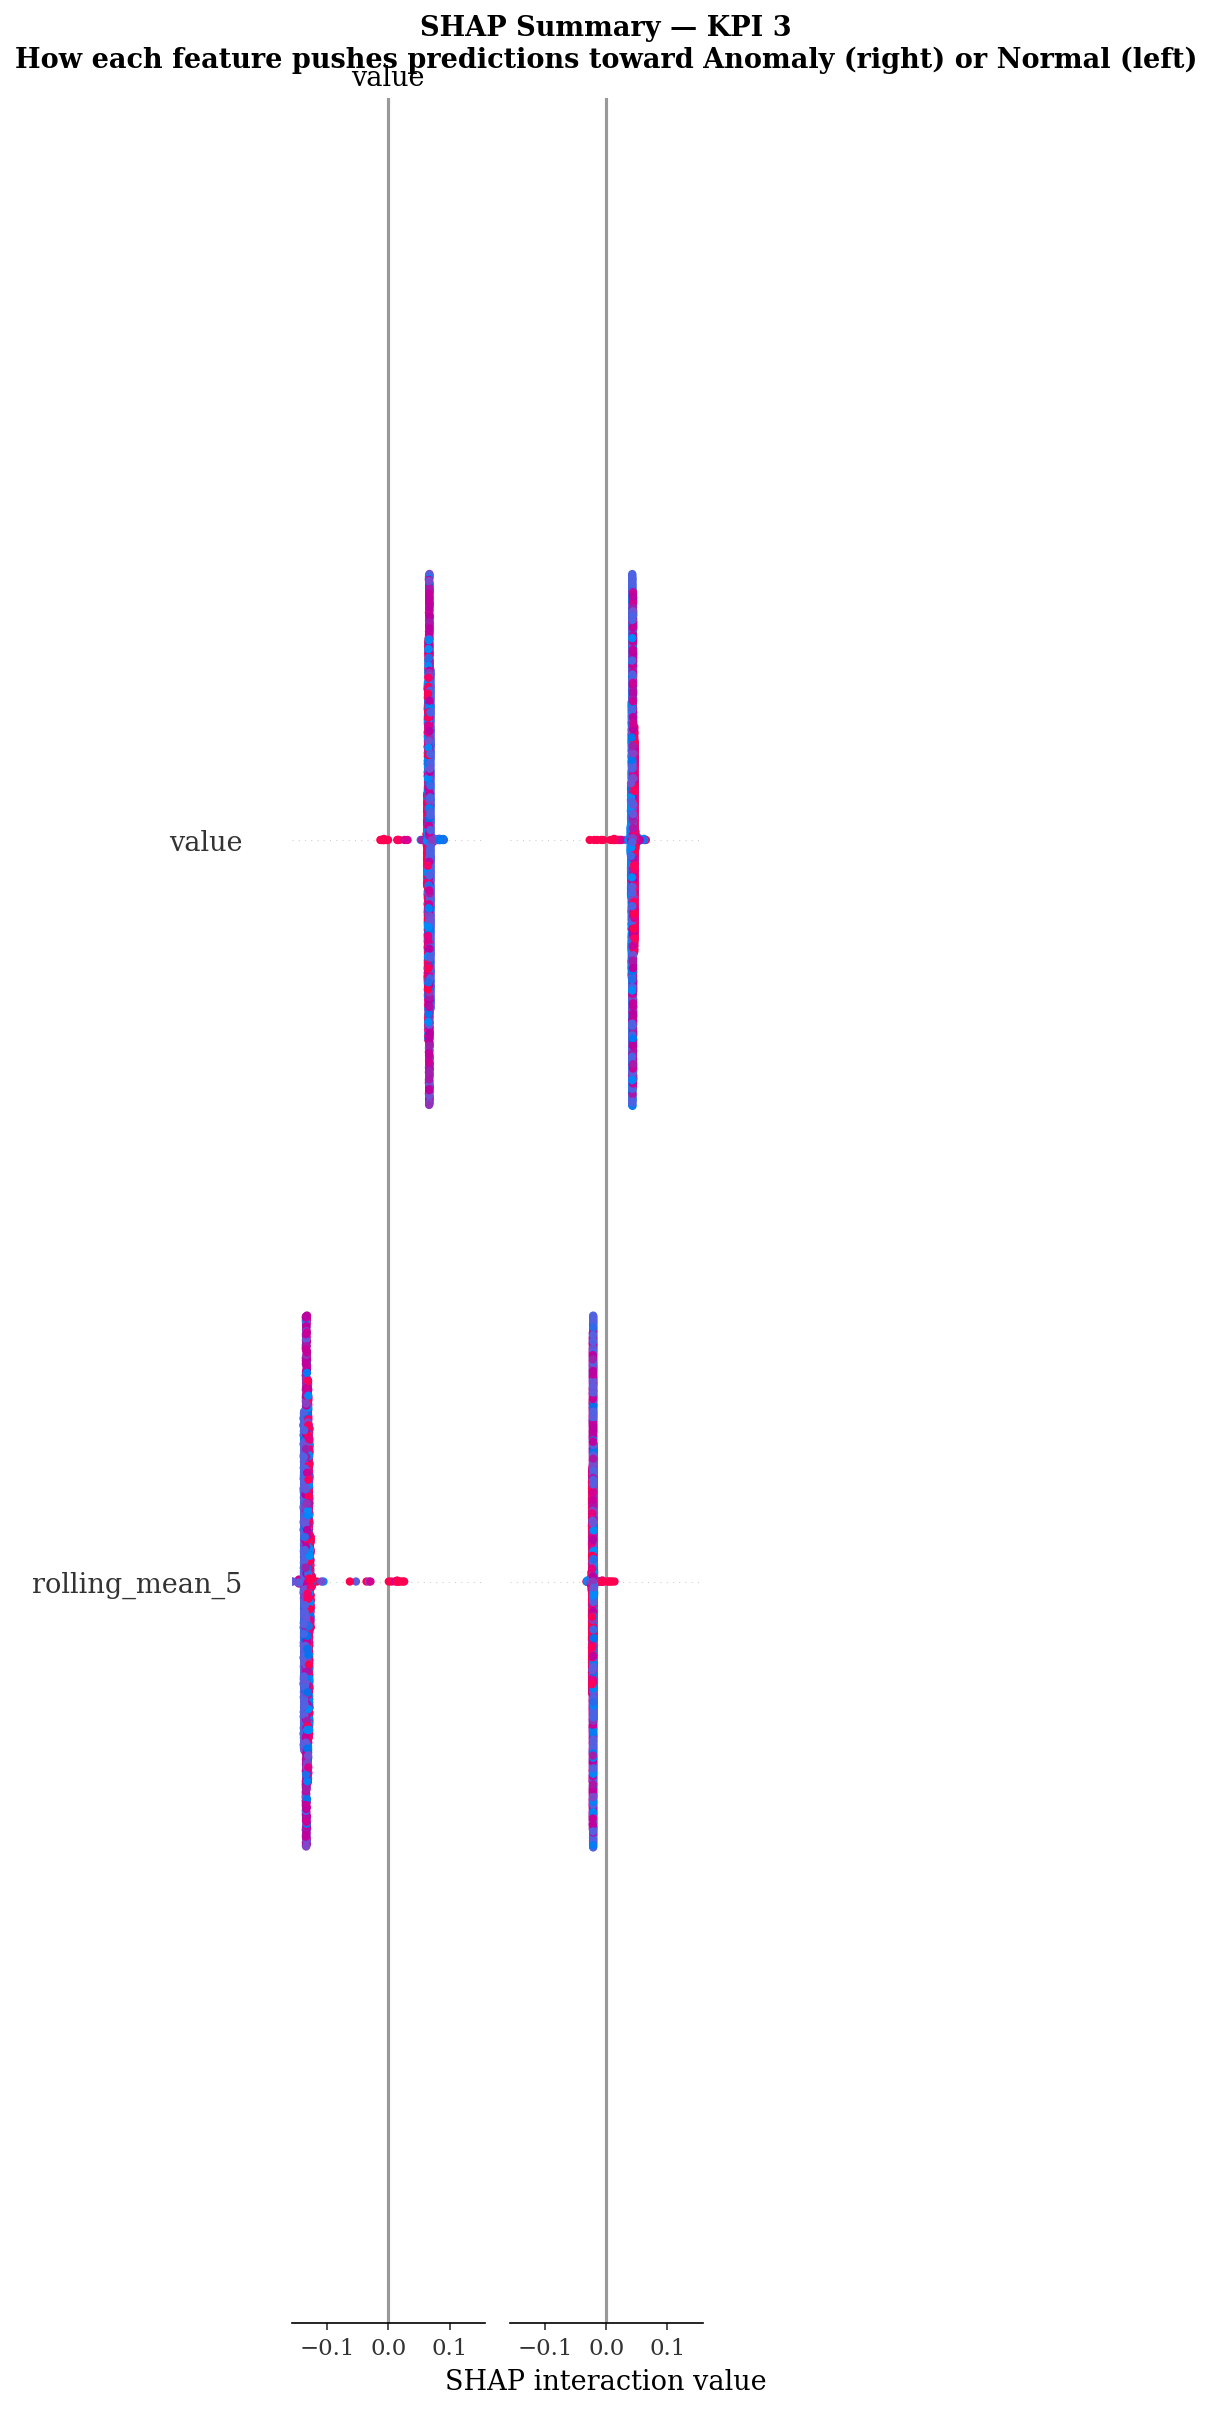

In [7]:
# SHAP Summary Plot (beeswarm)
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_anomaly, X_sample,
    feature_names=feature_columns,
    show=False,
    max_display=19
)
plt.title(f'SHAP Summary — {best_kpi}\n'
          f'How each feature pushes predictions toward Anomaly (right) or Normal (left)',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig_supp_shap_beeswarm.png', dpi=200, bbox_inches='tight')
plt.show()

<Figure size 1500x900 with 0 Axes>

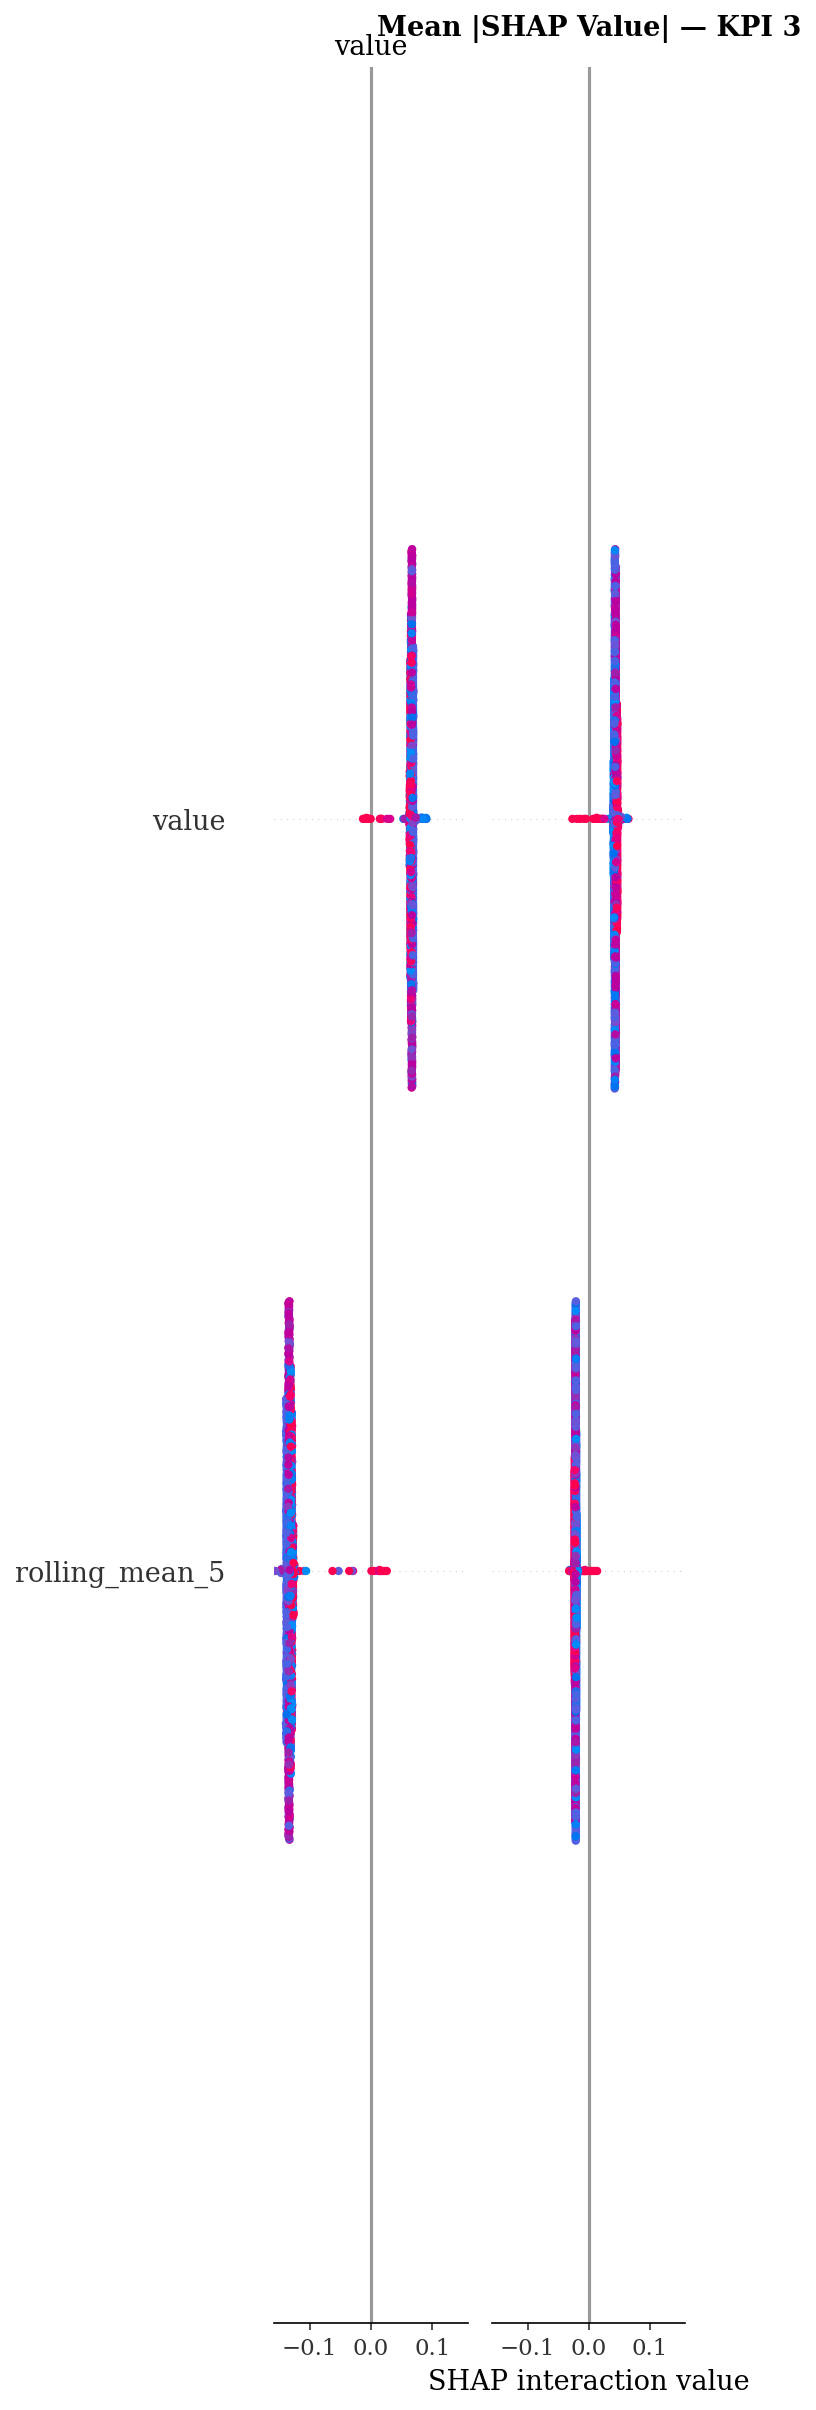

In [8]:
# SHAP Bar Plot — mean absolute SHAP values
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_anomaly, X_sample,
    feature_names=feature_columns,
    plot_type='bar',
    show=False,
    max_display=19
)
plt.title(f'Mean |SHAP Value| — {best_kpi}',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig_supp_shap_bar.png', dpi=200, bbox_inches='tight')
plt.show()

## 3. SHAP for Multiple KPIs — Proving Features Differ

Run SHAP on all 3 representative KPIs and compare.
This visually proves that different signals need different detection strategies.

In [11]:
# SHAP analysis for all 3 representative KPIs
shap_results = {}

for kpi_name in [best_kpi, mid_kpi, worst_kpi]:
    print(f'Computing SHAP for {kpi_name}...')
    model = kpi_models[kpi_name]['model']
    X_test = kpi_data_splits[kpi_name]['X_test']

    sample_size = min(1500, len(X_test))
    np.random.seed(42)
    idx = np.random.choice(len(X_test), sample_size, replace=False)
    X_s = X_test[idx]

    explainer = shap.TreeExplainer(model)
    sv = explainer.shap_values(X_s)
    if isinstance(sv, list):
        sv = sv[1]

    # Mean absolute SHAP per feature
    mean_shap = np.abs(sv).mean(axis=0)
    shap_results[kpi_name] = {
        'mean_shap': dict(zip(feature_columns, mean_shap)),
        'shap_values': sv,
        'X_sample': X_s
    }

print('Done!')

Computing SHAP for KPI 3...
Computing SHAP for KPI 19...
Computing SHAP for KPI 15...
Done!


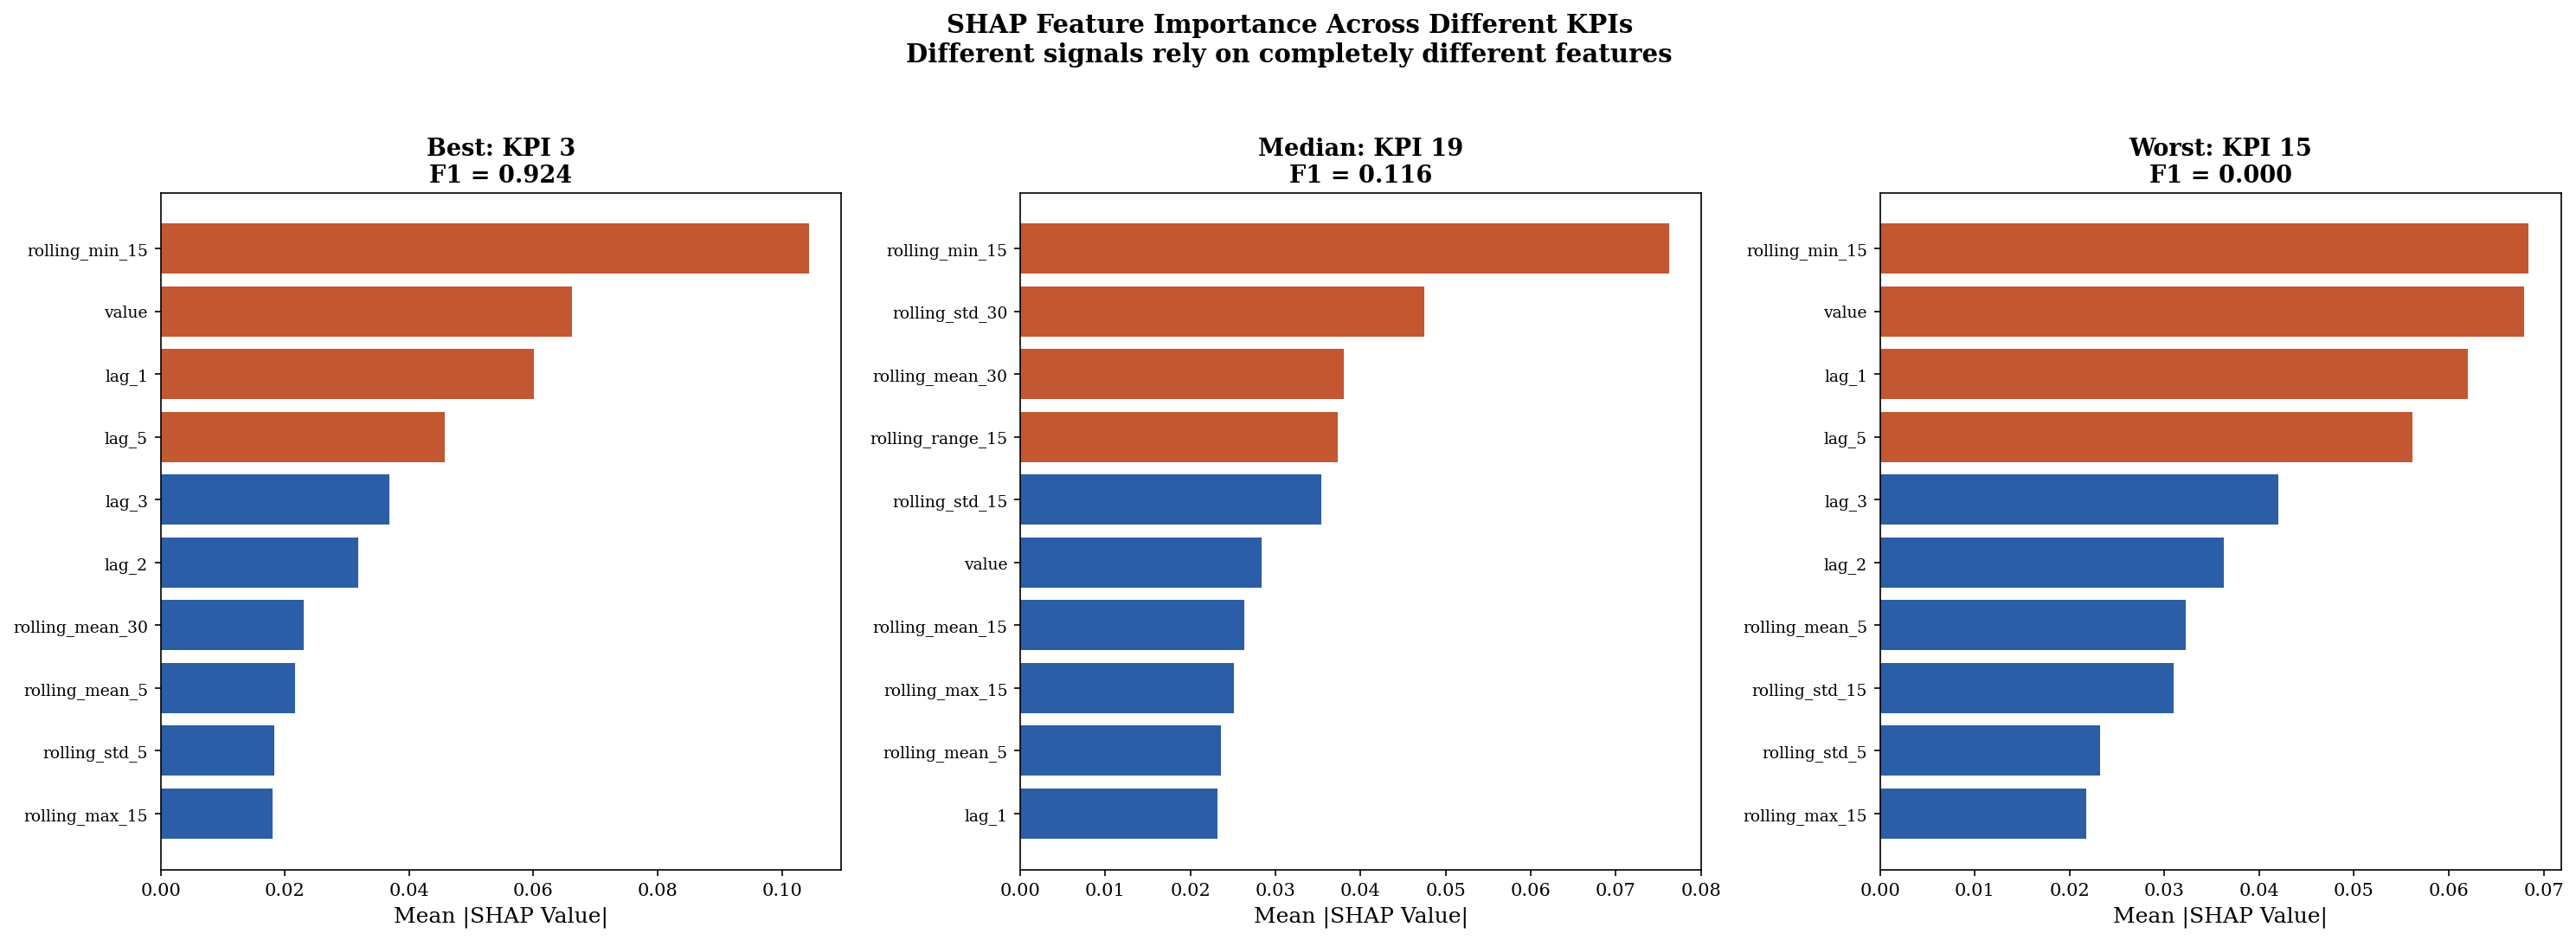


Top 3 features per KPI (by SHAP):
  KPI 3: rolling_min_15 (0.1044), value (0.0662), lag_1 (0.0601)
  KPI 19: rolling_min_15 (0.0762), rolling_std_30 (0.0475), rolling_mean_30 (0.0380)
  KPI 15: rolling_min_15 (0.0684), value (0.0680), lag_1 (0.0620)


In [15]:
# PAPER FIGURE 5: Side-by-side SHAP comparison across 3 representative KPIs
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for idx, kpi_name in enumerate([best_kpi, mid_kpi, worst_kpi]):
    f1 = kpi_data_splits[kpi_name]['f1']
    mean_shap = shap_results[kpi_name]['mean_shap']
    sorted_features = sorted(mean_shap.items(), key=lambda x: x[1], reverse=True)
    names = [f[0] for f in sorted_features[:10]]
    values = [f[1] for f in sorted_features[:10]]

    colors = ['#C25732' if v > np.mean(values) else '#2B5EA7' for v in values]
    axes[idx].barh(range(len(names)), values[::-1], color=colors[::-1])
    axes[idx].set_yticks(range(len(names)))
    axes[idx].set_yticklabels(names[::-1], fontsize=9)
    axes[idx].set_xlabel('Mean |SHAP Value|')

    label = ['Best', 'Median', 'Worst'][idx]
    axes[idx].set_title(f'{label}: {kpi_name}\nF1 = {f1:.3f}', fontweight='bold')

plt.suptitle('SHAP Feature Importance Across Different KPIs\n'
             'Different signals rely on completely different features',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig05_shap_beeswarm.png', dpi=300, bbox_inches='tight')
plt.show()

print('\nTop 3 features per KPI (by SHAP):')
for kpi_name in [best_kpi, mid_kpi, worst_kpi]:
    mean_shap = shap_results[kpi_name]['mean_shap']
    top3 = sorted(mean_shap.items(), key=lambda x: x[1], reverse=True)[:3]
    top3_str = ', '.join([f'{n} ({v:.4f})' for n, v in top3])
    print(f'  {kpi_name}: {top3_str}')

## 4. SHAP Dependence Plots — How Features Drive Predictions

Dependence plots show the relationship between a feature's value and its
SHAP contribution. This reveals non-linear patterns the model learned.

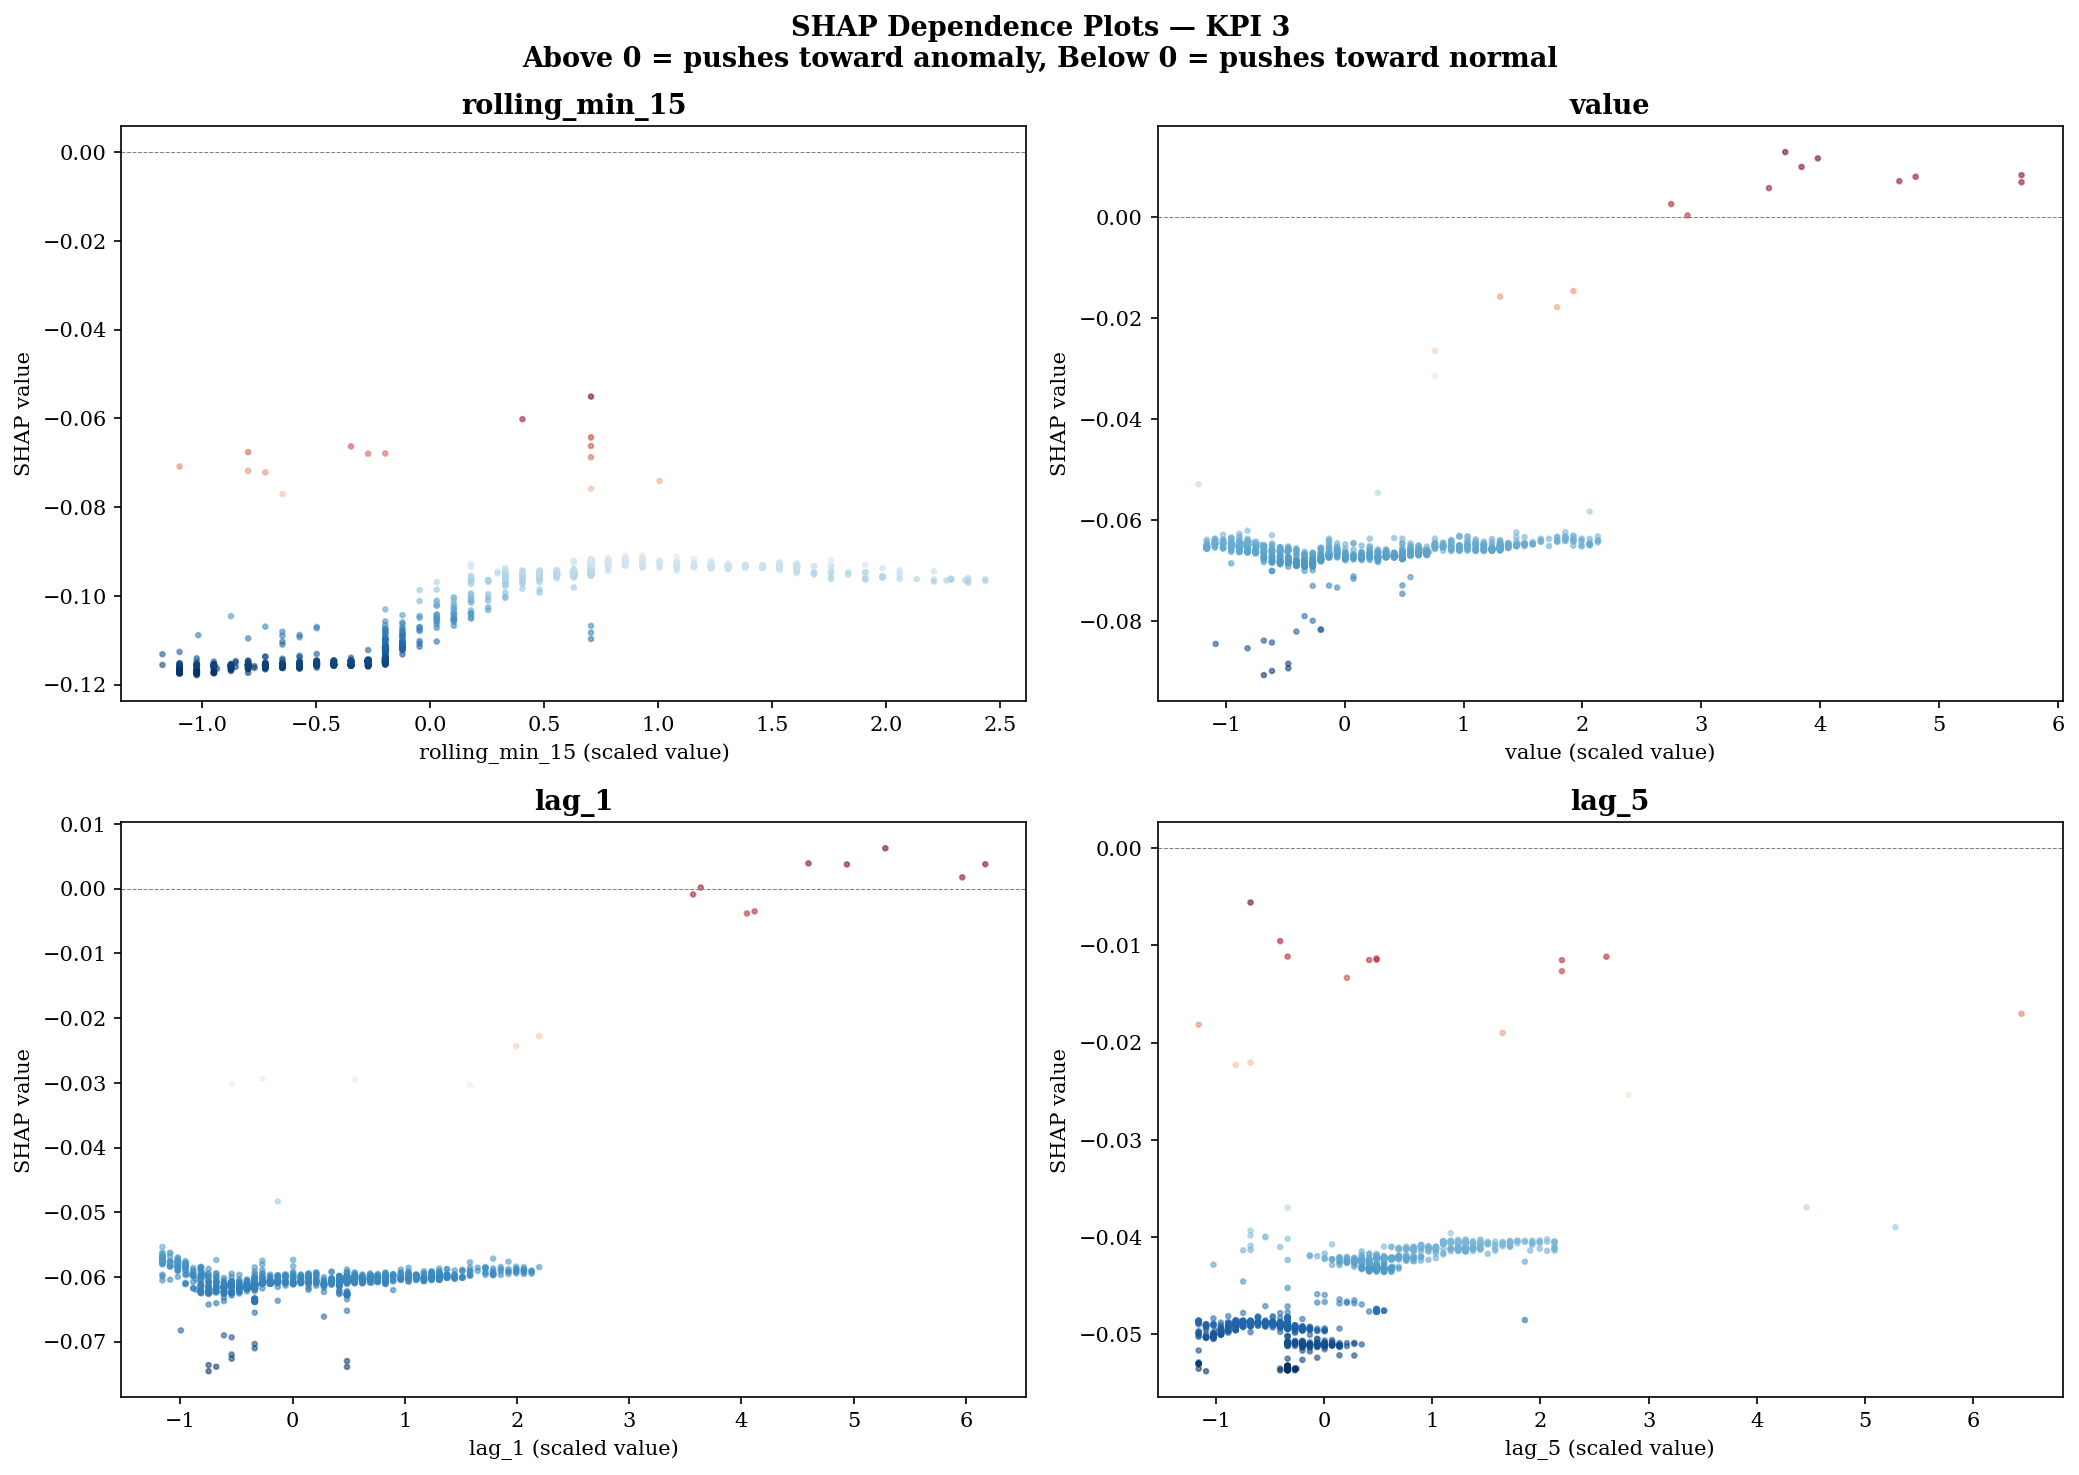

In [16]:
# PAPER FIGURE 6: Dependence plots for top 4 features of best KPI
mean_shap = shap_results[best_kpi]['mean_shap']
top_features = sorted(mean_shap.items(), key=lambda x: x[1], reverse=True)[:4]
top_feat_names = [f[0] for f in top_features]
top_feat_indices = [feature_columns.index(f) for f in top_feat_names]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

sv = shap_results[best_kpi]['shap_values']
X_s = shap_results[best_kpi]['X_sample']

for idx, (feat_name, feat_idx) in enumerate(zip(top_feat_names, top_feat_indices)):
    ax = axes[idx]
    scatter = ax.scatter(
        X_s[:, feat_idx], sv[:, feat_idx],
        c=sv[:, feat_idx], cmap='RdBu_r',
        s=5, alpha=0.5
    )
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.set_xlabel(f'{feat_name} (scaled value)', fontsize=10)
    ax.set_ylabel('SHAP value', fontsize=10)
    ax.set_title(f'{feat_name}', fontweight='bold')

plt.suptitle(f'SHAP Dependence Plots — {best_kpi}\n'
             f'Above 0 = pushes toward anomaly, Below 0 = pushes toward normal',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig06_shap_dependence.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. SHAP Waterfall — Explaining Individual Predictions

Pick one correctly detected anomaly and one missed anomaly.
Show exactly WHY the model made each decision.

True positives: 310 | False negatives: 35


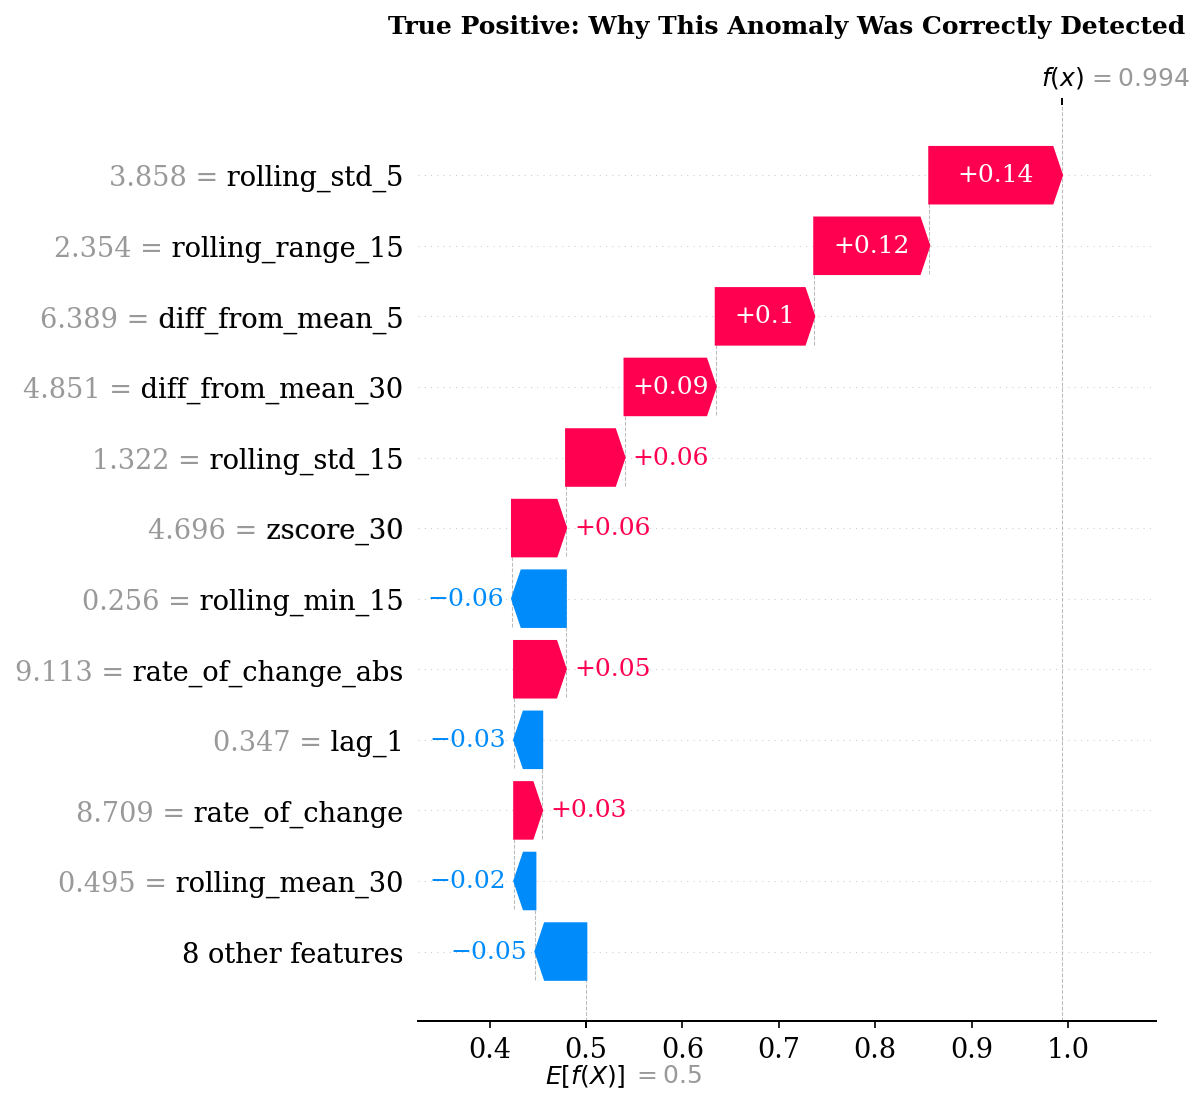

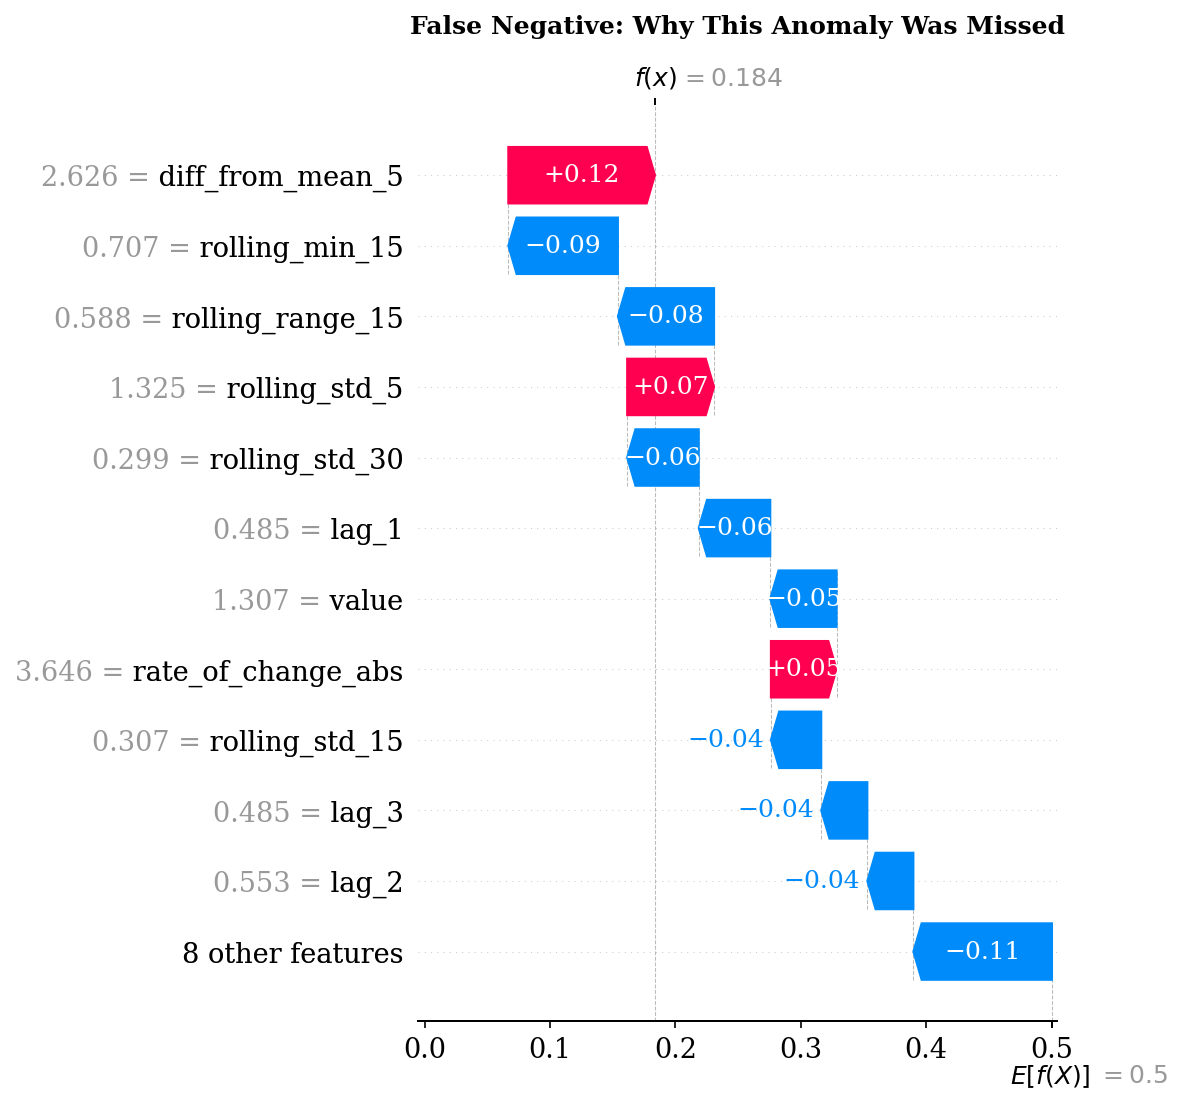

In [19]:
model = kpi_models[best_kpi]['model']
X_test_full = kpi_data_splits[best_kpi]['X_test']
y_test_full = kpi_data_splits[best_kpi]['y_test'].values
predictions = model.predict(X_test_full)

tp_indices = np.where((predictions == 1) & (y_test_full == 1))[0]
fn_indices = np.where((predictions == 0) & (y_test_full == 1))[0]

print(f'True positives: {len(tp_indices)} | False negatives: {len(fn_indices)}')

if len(tp_indices) > 0 and len(fn_indices) > 0:
    tp_idx = tp_indices[0]
    fn_idx = fn_indices[0]

    explainer = shap.TreeExplainer(model)
    two_points = np.vstack([X_test_full[tp_idx], X_test_full[fn_idx]])
    sv_two = explainer.shap_values(two_points)

    # Handle both formats: list [class0, class1] or 3D (samples, features, 2)
    if isinstance(sv_two, list):
        sv_two = sv_two[1]
    elif sv_two.ndim == 3:
        sv_two = sv_two[:, :, 1]

    # Get base value for anomaly class
    if isinstance(explainer.expected_value, list):
        base_val = float(explainer.expected_value[1])
    elif hasattr(explainer.expected_value, '__len__') and len(explainer.expected_value) > 1:
        base_val = float(explainer.expected_value[1])
    else:
        base_val = float(explainer.expected_value)

    shap_explanation_tp = shap.Explanation(
        values=sv_two[0],
        base_values=base_val,
        data=two_points[0],
        feature_names=feature_columns
    )
    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(shap_explanation_tp, show=False, max_display=12)
    plt.title('True Positive: Why This Anomaly Was Correctly Detected',
              fontweight='bold', fontsize=12, pad=15)
    plt.tight_layout()
    plt.savefig(f'{FIGURE_DIR}/fig_supp_waterfall_tp.png', dpi=200, bbox_inches='tight')
    plt.show()

    shap_explanation_fn = shap.Explanation(
        values=sv_two[1],
        base_values=base_val,
        data=two_points[1],
        feature_names=feature_columns
    )
    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(shap_explanation_fn, show=False, max_display=12)
    plt.title('False Negative: Why This Anomaly Was Missed',
              fontweight='bold', fontsize=12, pad=15)
    plt.tight_layout()
    plt.savefig(f'{FIGURE_DIR}/fig_supp_waterfall_fn.png', dpi=200, bbox_inches='tight')
    plt.show()
else:
    print('Not enough TP or FN to compare.')


## Additional Publication Figures
#
# The cells below generate supplementary figures. Primary paper figures
# (Fig 2-4) are generated in `03_per_kpi_models.ipynb`.
# Figures 5-6 are generated above (SHAP comparison + dependence plots).

<Figure size 1500x900 with 0 Axes>

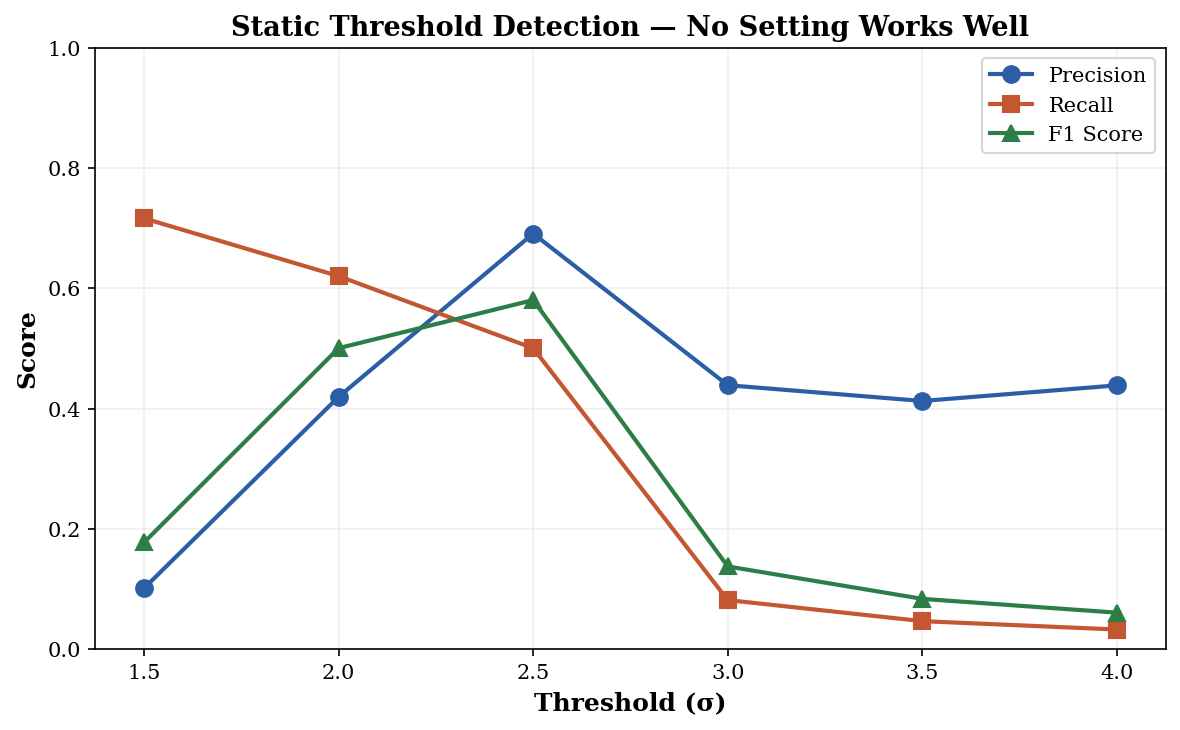

In [18]:
# Supplementary: Threshold performance across sigma values
sigma_results = []
for sigma in [1.5, 2.0, 2.5, 3.0, 3.5, 4.0]:
    all_true, all_pred = [], []
    for kpi_id in kpi_ids:
        kpi_data = featured_df[featured_df['KPI ID'] == kpi_id].sort_values('timestamp')
        split_idx = int(len(kpi_data) * 0.7)
        train_k, test_k = kpi_data.iloc[:split_idx], kpi_data.iloc[split_idx:]
        if test_k['label'].sum() == 0 or train_k['label'].sum() == 0:
            continue
        m, s = train_k['value'].mean(), train_k['value'].std()
        pred = ((test_k['value'] > m + sigma * s) | (test_k['value'] < m - sigma * s)).astype(int)
        all_true.extend(test_k['label'].values)
        all_pred.extend(pred.values)
    sigma_results.append({
        'sigma': sigma,
        'Precision': precision_score(all_true, all_pred, zero_division=0),
        'Recall': recall_score(all_true, all_pred, zero_division=0),
        'F1': f1_score(all_true, all_pred, zero_division=0)
    })

sr_df = pd.DataFrame(sigma_results)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sr_df['sigma'], sr_df['Precision'], 'o-', color='#2B5EA7', linewidth=2, markersize=8, label='Precision')
ax.plot(sr_df['sigma'], sr_df['Recall'], 's-', color='#C25732', linewidth=2, markersize=8, label='Recall')
ax.plot(sr_df['sigma'], sr_df['F1'], '^-', color='#2D7D46', linewidth=2, markersize=8, label='F1 Score')
ax.set_xlabel('Threshold (σ)', fontweight='bold')
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Static Threshold Detection — No Setting Works Well', fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.0)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig_supp_threshold_sweep.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 2: ML vs Gut Feel — Per-KPI Win Rates

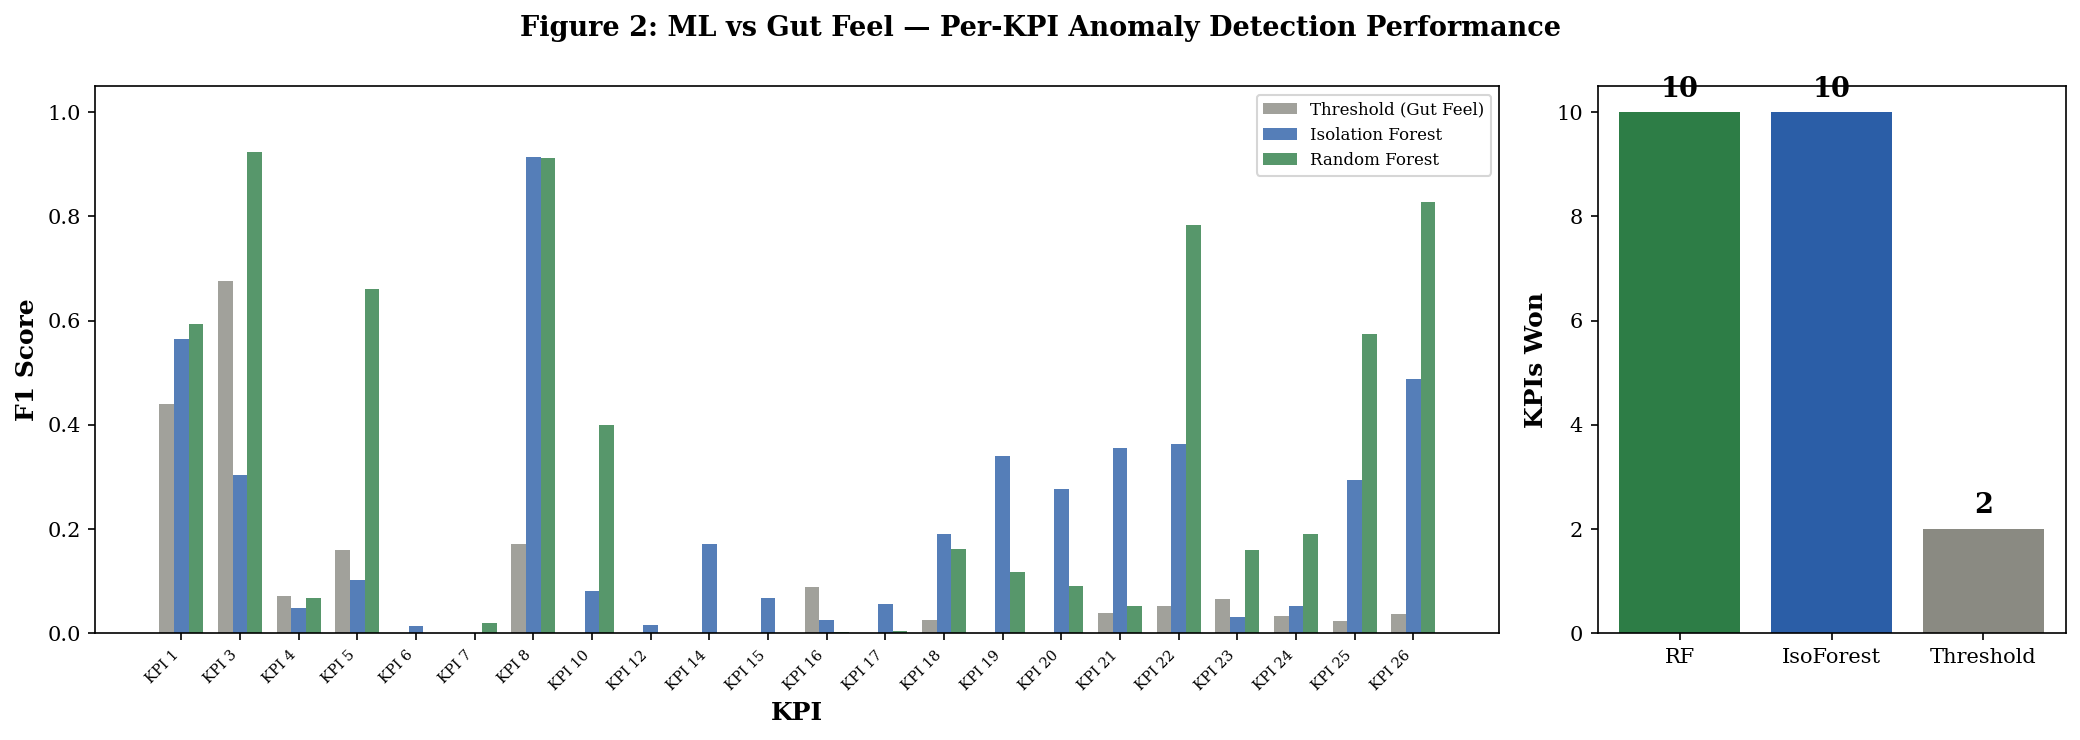


ML approaches win 20/22 KPIs (91%)
Threshold (gut feel) wins only 2/22 KPIs (9%)


In [20]:
# FIGURE 2: Rebuild per-KPI comparison with all 3 methods
all_kpi_results = []

for i, kpi_id in enumerate(kpi_ids):
    kpi_data = featured_df[featured_df['KPI ID'] == kpi_id].sort_values('timestamp')
    split_idx = int(len(kpi_data) * 0.7)
    train_k = kpi_data.iloc[:split_idx]
    test_k = kpi_data.iloc[split_idx:]
    y_train = train_k['label']
    y_test = test_k['label']
    if y_train.sum() == 0 or y_test.sum() == 0:
        continue

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(train_k[feature_columns].fillna(0))
    X_te = scaler.transform(test_k[feature_columns].fillna(0))

    # Threshold
    m, s = train_k['value'].mean(), train_k['value'].std()
    t_pred = ((test_k['value'] > m + 3*s) | (test_k['value'] < m - 3*s)).astype(int).values

    # Isolation Forest
    iso = IsolationForest(contamination=max(y_train.mean(), 0.01),
                          n_estimators=100, random_state=42)
    iso.fit(X_tr)
    i_pred = (iso.predict(X_te) == -1).astype(int)

    # Random Forest
    rf = RandomForestClassifier(n_estimators=200, max_depth=10,
                                class_weight='balanced', random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_train)
    r_pred = rf.predict(X_te)

    f1_t = f1_score(y_test, t_pred, zero_division=0)
    f1_i = f1_score(y_test, i_pred, zero_division=0)
    f1_r = f1_score(y_test, r_pred, zero_division=0)
    winner = max({'Threshold': f1_t, 'IsoForest': f1_i, 'RF': f1_r}.items(), key=lambda x: x[1])

    all_kpi_results.append({
        'KPI': f'KPI {i+1}', 'Threshold': f1_t,
        'IsoForest': f1_i, 'RF': f1_r, 'Winner': winner[0]
    })

akr_df = pd.DataFrame(all_kpi_results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5),
                                gridspec_kw={'width_ratios': [3, 1]})

# Left: grouped bar
x = np.arange(len(akr_df))
w = 0.25
ax1.bar(x - w, akr_df['Threshold'], w, label='Threshold (Gut Feel)', color='#8A8A82', alpha=0.8)
ax1.bar(x, akr_df['IsoForest'], w, label='Isolation Forest', color='#2B5EA7', alpha=0.8)
ax1.bar(x + w, akr_df['RF'], w, label='Random Forest', color='#2D7D46', alpha=0.8)
ax1.set_xlabel('KPI', fontweight='bold')
ax1.set_ylabel('F1 Score', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(akr_df['KPI'], rotation=45, ha='right', fontsize=7)
ax1.legend(fontsize=8, loc='upper right')
ax1.set_ylim(0, 1.05)

# Right: win count
wins = akr_df['Winner'].value_counts()
cmap = {'RF': '#2D7D46', 'IsoForest': '#2B5EA7', 'Threshold': '#8A8A82'}
bc = [cmap.get(w, '#666') for w in wins.index]
ax2.bar(wins.index, wins.values, color=bc)
ax2.set_ylabel('KPIs Won', fontweight='bold')
for j, v in enumerate(wins.values):
    ax2.text(j, v + 0.3, str(v), ha='center', fontweight='bold', fontsize=13)

plt.suptitle('Figure 2: ML vs Gut Feel — Per-KPI Anomaly Detection Performance',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig2_ml_vs_gutfeel.png', dpi=300, bbox_inches='tight')
plt.show()

ml_wins = len(akr_df[akr_df['Winner'] != 'Threshold'])
total = len(akr_df)
print(f'\nML approaches win {ml_wins}/{total} KPIs ({ml_wins/total*100:.0f}%)')
print(f'Threshold (gut feel) wins only {total - ml_wins}/{total} KPIs ({(total-ml_wins)/total*100:.0f}%)')

## Figure 3: Ablation Curve — Proving Signal Waste

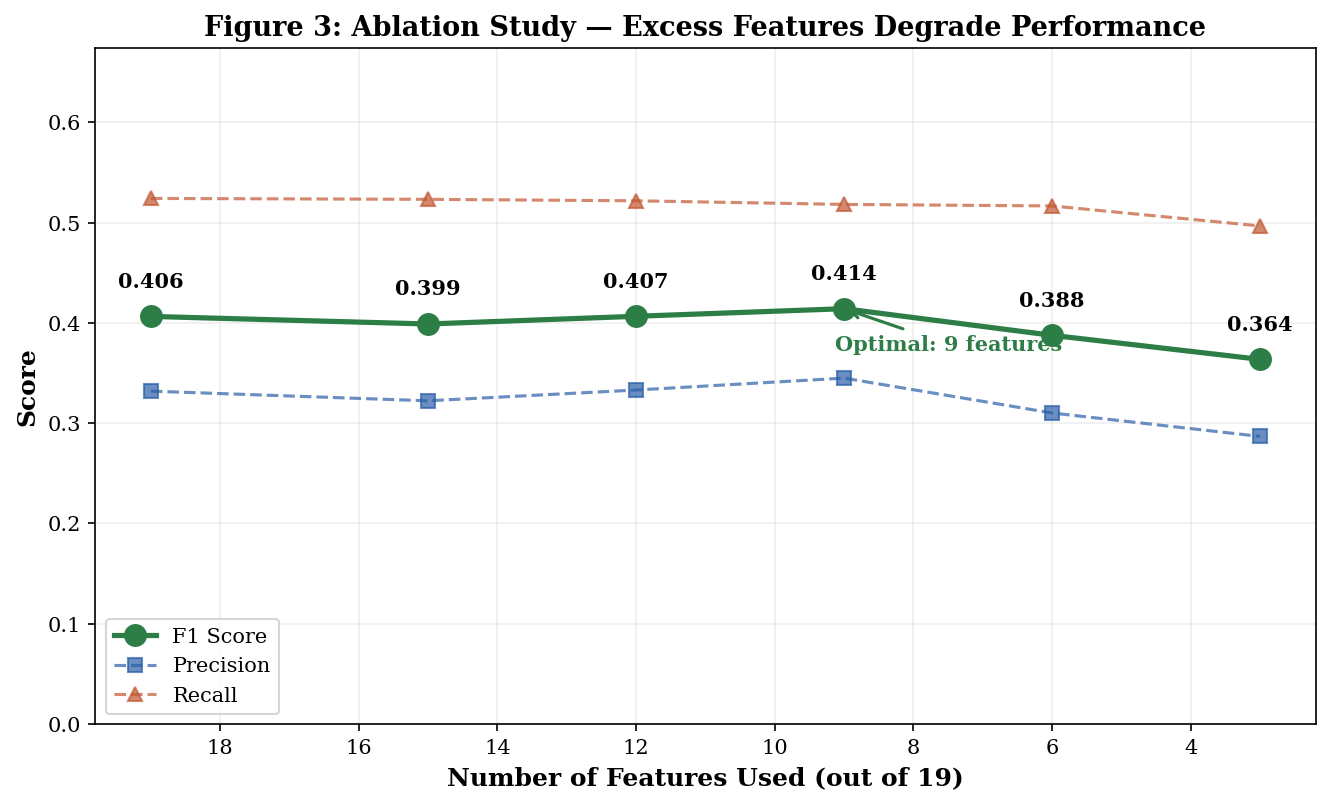


Full model (19 features): F1 = 0.4065
Optimal (9 features):   F1 = 0.4142
Removing 10 features improved F1 by +1.9%


In [21]:
# FIGURE 3: Ablation study (recompute for publication quality)
# Use averaged feature importance from all KPI models to rank features
avg_importance = {}
for kpi_name, data in kpi_models.items():
    imp = data['model'].feature_importances_
    for fi, col in enumerate(feature_columns):
        avg_importance[col] = avg_importance.get(col, []) + [imp[fi]]

avg_importance = {k: np.mean(v) for k, v in avg_importance.items()}
feature_order = sorted(avg_importance.keys(), key=lambda x: avg_importance[x], reverse=True)

ablation = []
for n_feat in [19, 15, 12, 9, 6, 3]:
    top_n = feature_order[:n_feat]
    all_t, all_p = [], []
    for kpi_id in kpi_ids:
        kpi_data = featured_df[featured_df['KPI ID'] == kpi_id].sort_values('timestamp')
        split_idx = int(len(kpi_data) * 0.7)
        tr, te = kpi_data.iloc[:split_idx], kpi_data.iloc[split_idx:]
        yt, yv = tr['label'], te['label']
        if yt.sum() == 0 or yv.sum() == 0:
            continue
        sc = StandardScaler()
        Xtr = sc.fit_transform(tr[top_n].fillna(0))
        Xte = sc.transform(te[top_n].fillna(0))
        rf = RandomForestClassifier(n_estimators=200, max_depth=10,
                                    class_weight='balanced', random_state=42, n_jobs=-1)
        rf.fit(Xtr, yt)
        all_t.extend(yv.values)
        all_p.extend(rf.predict(Xte))
    ablation.append({
        'n': n_feat,
        'removed_pct': (19 - n_feat) / 19 * 100,
        'F1': f1_score(all_t, all_p, zero_division=0),
        'Precision': precision_score(all_t, all_p, zero_division=0),
        'Recall': recall_score(all_t, all_p, zero_division=0)
    })

abl_df = pd.DataFrame(ablation)

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(abl_df['n'], abl_df['F1'], 'o-', color='#2D7D46',
        linewidth=2.5, markersize=10, label='F1 Score', zorder=5)
ax.plot(abl_df['n'], abl_df['Precision'], 's--', color='#2B5EA7',
        linewidth=1.5, markersize=7, alpha=0.7, label='Precision')
ax.plot(abl_df['n'], abl_df['Recall'], '^--', color='#C25732',
        linewidth=1.5, markersize=7, alpha=0.7, label='Recall')

for _, row in abl_df.iterrows():
    ax.annotate(f'{row["F1"]:.3f}', (row['n'], row['F1']),
                textcoords='offset points', xytext=(0, 14),
                ha='center', fontweight='bold', fontsize=10)

# Highlight the sweet spot
best_row = abl_df.loc[abl_df['F1'].idxmax()]
ax.annotate(f'Optimal: {int(best_row["n"])} features',
            (best_row['n'], best_row['F1']),
            textcoords='offset points', xytext=(50, -20),
            ha='center', fontsize=10, color='#2D7D46', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#2D7D46', lw=1.5))

ax.set_xlabel('Number of Features Used (out of 19)', fontweight='bold')
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Figure 3: Ablation Study — Excess Features Degrade Performance',
             fontweight='bold')
ax.legend(loc='lower left')
ax.set_ylim(0, max(abl_df['Recall'].max(), abl_df['F1'].max()) + 0.15)
ax.grid(True, alpha=0.2)
ax.invert_xaxis()

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig3_ablation.png', dpi=300, bbox_inches='tight')
plt.show()

full_f1 = abl_df.iloc[0]['F1']
best_f1 = best_row['F1']
print(f'\nFull model (19 features): F1 = {full_f1:.4f}')
print(f'Optimal ({int(best_row["n"])} features):   F1 = {best_f1:.4f}')
print(f'Removing {19 - int(best_row["n"])} features improved F1 by {(best_f1-full_f1)/full_f1*100:+.1f}%')

## Figure 4: Feature Importance with SHAP (Publication Version)

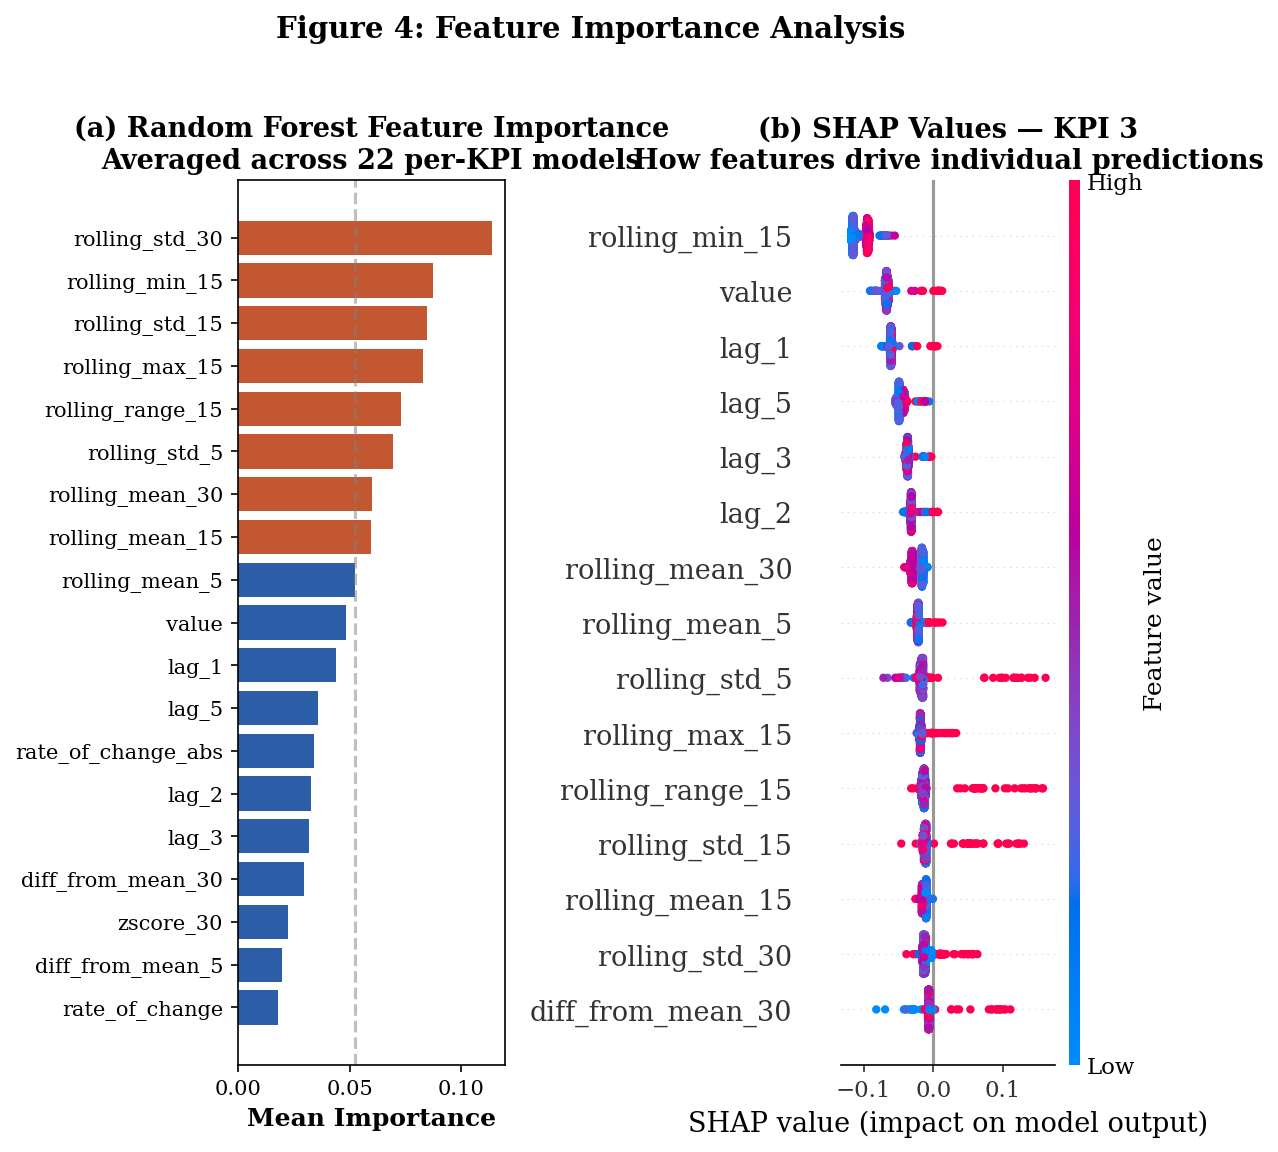

In [22]:
# FIGURE 4: Combined SHAP + RF importance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

# Left: RF feature importance (averaged)
imp_series = pd.Series(avg_importance).sort_values(ascending=True)
colors = ['#C25732' if v > imp_series.mean() else '#2B5EA7' for v in imp_series.values]
ax1.barh(imp_series.index, imp_series.values, color=colors)
ax1.set_xlabel('Mean Importance', fontweight='bold')
ax1.set_title('(a) Random Forest Feature Importance\nAveraged across 22 per-KPI models',
              fontweight='bold')
ax1.axvline(imp_series.mean(), color='gray', linestyle='--', alpha=0.5)

# Right: SHAP beeswarm for best KPI
plt.sca(ax2)
shap.summary_plot(
    shap_results[best_kpi]['shap_values'],
    shap_results[best_kpi]['X_sample'],
    feature_names=feature_columns,
    show=False,
    max_display=15
)
ax2.set_title(f'(b) SHAP Values — {best_kpi}\nHow features drive individual predictions',
              fontweight='bold')

plt.suptitle('Figure 4: Feature Importance Analysis',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig4_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 5: Research Summary — All Key Numbers

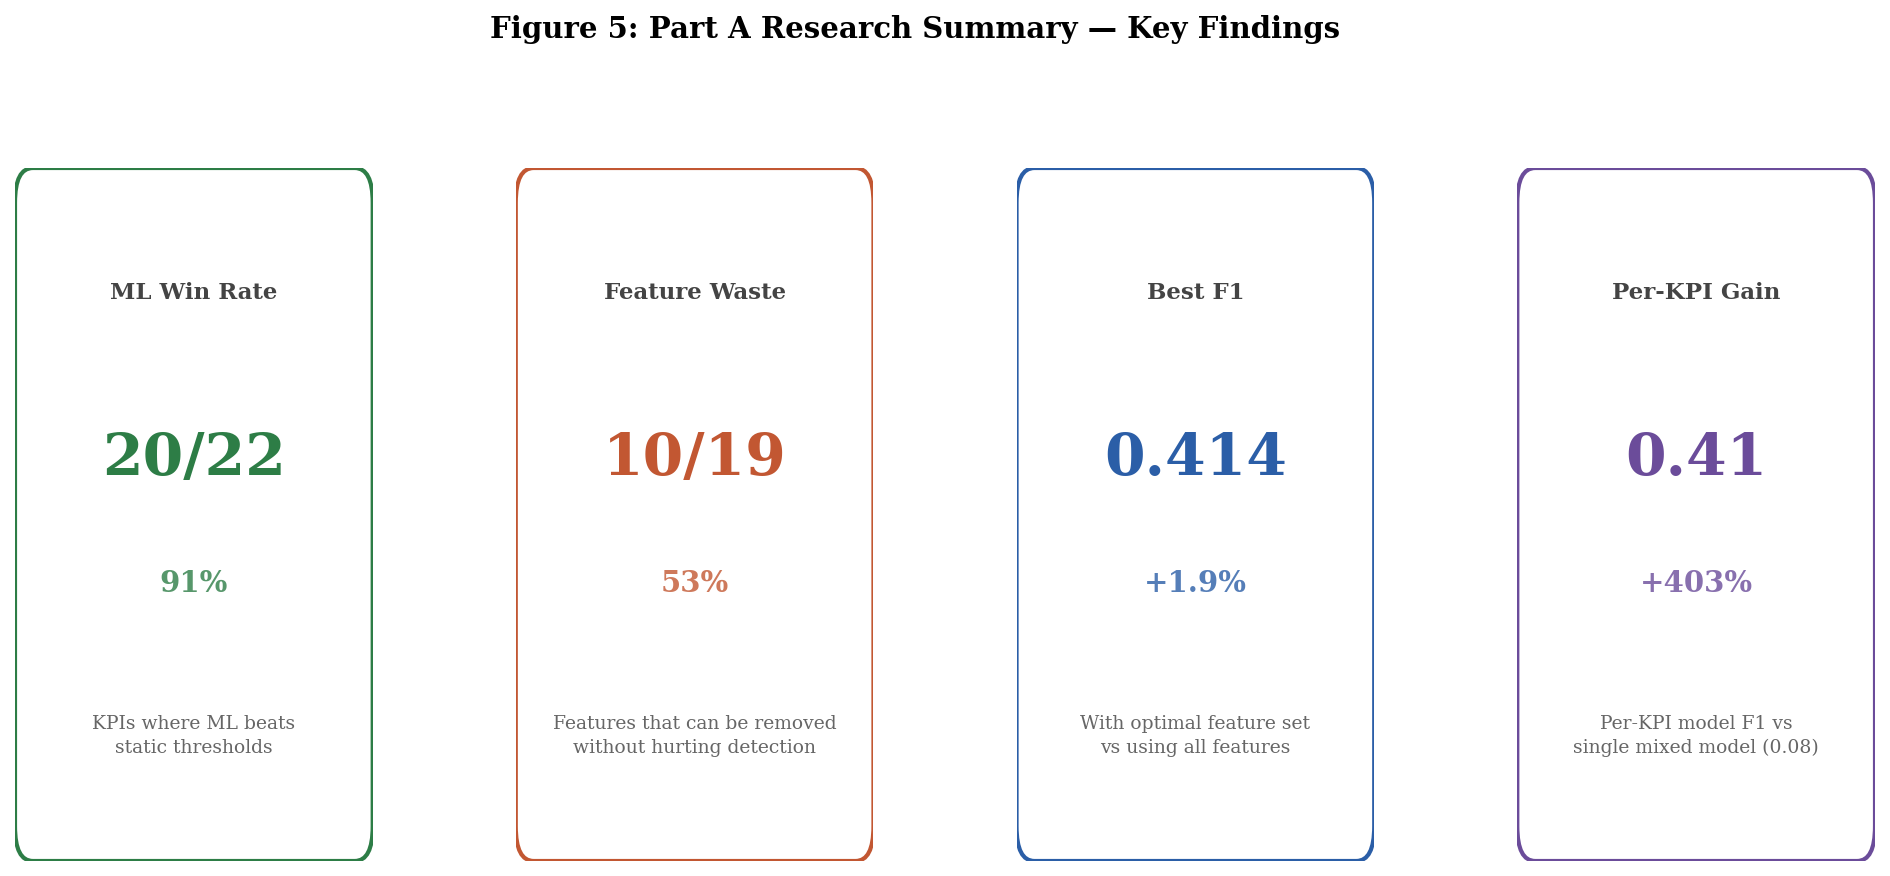

In [23]:
# FIGURE 5: Summary dashboard
fig = plt.figure(figsize=(16, 6))
gs = gridspec.GridSpec(1, 4, width_ratios=[1, 1, 1, 1], wspace=0.4)

# Stat tiles
stats = [
    ('ML Win Rate', f'{ml_wins}/{total}', f'{ml_wins/total*100:.0f}%',
     'KPIs where ML beats\nstatic thresholds', '#2D7D46'),
    ('Feature Waste', '10/19', '53%',
     'Features that can be removed\nwithout hurting detection', '#C25732'),
    ('Best F1', f'{best_f1:.3f}', f'+{(best_f1-full_f1)/full_f1*100:.1f}%',
     'With optimal feature set\nvs using all features', '#2B5EA7'),
    ('Per-KPI Gain', '0.41', '+403%',
     'Per-KPI model F1 vs\nsingle mixed model (0.08)', '#6B4C9A')
]

for idx, (title, big_num, subtitle, desc, color) in enumerate(stats):
    ax = fig.add_subplot(gs[idx])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    # Background card
    from matplotlib.patches import FancyBboxPatch
    card = FancyBboxPatch((0.05, 0.05), 0.9, 0.9,
                          boxstyle='round,pad=0.05',
                          facecolor='white', edgecolor=color, linewidth=2)
    ax.add_patch(card)

    ax.text(0.5, 0.82, title, ha='center', va='center',
            fontsize=11, fontweight='bold', color='#444')
    ax.text(0.5, 0.58, big_num, ha='center', va='center',
            fontsize=28, fontweight='bold', color=color)
    ax.text(0.5, 0.40, subtitle, ha='center', va='center',
            fontsize=14, fontweight='bold', color=color, alpha=0.8)
    ax.text(0.5, 0.18, desc, ha='center', va='center',
            fontsize=9, color='#666', linespacing=1.4)

plt.suptitle('Figure 5: Part A Research Summary — Key Findings',
             fontsize=14, fontweight='bold', y=1.05)
plt.savefig(f'{FIGURE_DIR}/fig5_summary.png', dpi=300, bbox_inches='tight')
plt.show()

## Summary — All Part A Figures
#
# | Paper Fig | File | Description |
# |-----------|------|-------------|
# | Fig 2 | `fig02_per_kpi_comparison.png` | Per-KPI F1 comparison (from NB 03) |
# | Fig 3 | `fig03_f1_difference_distribution.png` | ML − threshold F1 gap (from NB 03) |
# | Fig 4 | `fig04_ablation_curve.png` | Feature removal vs performance (from NB 03) |
# | Fig 5 | `fig05_shap_beeswarm.png` | SHAP comparison across 3 KPIs |
# | Fig 6 | `fig06_shap_dependence.png` | Feature dependence plots |
# | Supp | `fig_supp_feature_heatmap.png` | Per-KPI importance heatmap (from NB 03) |
# | Supp | `fig_supp_shap_beeswarm.png` | Full SHAP beeswarm (best KPI) |
# | Supp | `fig_supp_waterfall_*.png` | TP/FN waterfall explanations |
# | Supp | `fig_supp_threshold_sweep.png` | σ sweep performance |
#
# **Part A complete.** Next: Part B notebooks.